# Neural network forecasting with prediction window

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
df = pd.read_csv('csv_gold_price.csv')
df.head()

,Date,Price
0,1/1/2014,29542
1,1/2/2014,29975
2,1/3/2014,29727
3,1/4/2014,29279
4,1/5/2014,29119


In [3]:
df.index = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df[:5]

,Date,Price
Date,,
2014-01-01,1/1/2014,29542
2014-01-02,1/2/2014,29975
2014-01-03,1/3/2014,29727
2014-01-04,1/4/2014,29279
2014-01-05,1/5/2014,29119


<Axes: xlabel='Date'>

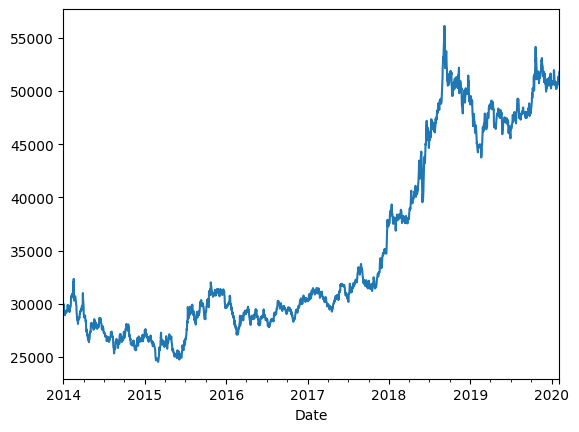

In [4]:
price_plot = df['Price']
price_plot.plot()

## Normalizing

In [5]:
def normalize(data):
    np_data = data.to_numpy()
    data_minimum = np.min(np_data)
    data_maximum = np.max(np_data)

    normalized_data = []
    for item in np_data:
        normalized_item =(item - data_minimum)/(data_maximum - data_minimum)
        normalized_data.append(normalized_item)

    return np.array(normalized_data), data_minimum, data_maximum, np_data

In [6]:
price_normalized, GLOBAL_MINIMUM, GLOBAL_MAXIMUM, price_np = normalize(price_plot)

## Prediction window

In [7]:
def define_prediction_window(np_price, window_size):
    X = []
    y = []
    for i in range(len(np_price)-window_size):
        input_data = [[a] for a in np_price[i:i+window_size]]
        X.append(input_data)
        label = np_price[i + window_size]
        y.append(label)
        
    return np.array(X),np.array(y)

In [8]:
WINDOW_SIZE = 5
X_normalized, y_normalized = define_prediction_window(price_normalized,WINDOW_SIZE)
X_normalized.shape, y_normalized.shape

((2222, 5, 1), (2222,))

## Split data

In [9]:
X_train_normalized, y_train_normalized = X_normalized[:2000], y_normalized[:2000]
X_test_normalized, y_test_normalized = X_normalized[2000:], y_normalized[2000:]

In [10]:
X_train_normalized.shape, y_train_normalized.shape, X_test_normalized.shape, y_test_normalized.shape

((2000, 5, 1), (2000,), (222, 5, 1), (222,))

## Build the neural network

In [ ]:
ACTIVATION_FUNCTION = tf.nn.sigmoid

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(5, 1)))
model.add(tf.keras.layers.Dense(units=128, activation=ACTIVATION_FUNCTION))
model.add(tf.keras.layers.Dense(units=1, activation=ACTIVATION_FUNCTION))

model.summary()

In [ ]:
#cp = tf.keras.callbacks.ModelCheckpoint('model1/',save_best_only=True)
ADAM_OPTIMAZER = tf.keras.optimizers.Adam(learning_rate=0.001)
SGD_OPTIMAZER = tf.keras.optimizers.SGD(learning_rate=0.001)
model.compile(optimizer=SGD_OPTIMAZER, loss=tf.keras.losses.MeanSquaredError(), metrics=[tf.keras.metrics.RootMeanSquaredError()])

In [ ]:
#model.fit(X_train_normalized, y_train_normalized, validation_data=(X_val_normalized, y_val_normalized),epochs=20, callbacks=[cp])
model.fit(X_normalized, y_normalized, epochs=2500)

In [ ]:
# from tensorflow.keras.models import load_model
# model = load_model('model1/')

In [ ]:
def denormalize(data, min, max):
    original_data_min = min
    original_data_max = max

    denormalized_data = []
    for predict in data:
        denormalized_predict = predict*(original_data_max - original_data_min) + original_data_min
        denormalized_data.append(denormalized_predict)
    
    return np.array(denormalized_data)

In [ ]:
train_predictions = model.predict(X_train_normalized).flatten()
train_predictions = denormalize(train_predictions, GLOBAL_MINIMUM, GLOBAL_MAXIMUM)
train_predictions = pd.DataFrame(data={'Train Predictions' : train_predictions, 'Actuals' : price_np[:2000]})
train_predictions

In [ ]:
plt.plot(train_predictions['Actuals'])
plt.plot(train_predictions['Train Predictions'])
plt.show()

## Adam Optimizer version

In [11]:
ACTIVATION_FUNCTION = tf.nn.sigmoid

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(5, 1)))
model.add(tf.keras.layers.Dense(units=128, activation=ACTIVATION_FUNCTION))
model.add(tf.keras.layers.Dense(units=64, activation=ACTIVATION_FUNCTION))
model.add(tf.keras.layers.Dense(units=1, activation=ACTIVATION_FUNCTION))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 5)                 0         
                                                                 
 dense (Dense)               (None, 128)               768       
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 9089 (35.50 KB)
Trainable params: 9089 (35.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [12]:
ADAM_OPTIMAZER = tf.keras.optimizers.Adam(learning_rate=0.001)
MSE_LOSS = tf.keras.losses.MeanSquaredError()
RMSE_ERROR = tf.keras.metrics.RootMeanSquaredError()
model.compile(optimizer=ADAM_OPTIMAZER, loss=MSE_LOSS, metrics=RMSE_ERROR)

In [13]:
model.fit(X_normalized, y_normalized, epochs=100, batch_size=1, verbose=2)

Epoch 1/100
2222/2222 - 4s - loss: 0.0114 - root_mean_squared_error: 0.1067 - 4s/epoch - 2ms/step
Epoch 2/100
2222/2222 - 3s - loss: 9.4919e-04 - root_mean_squared_error: 0.0308 - 3s/epoch - 1ms/step
Epoch 3/100
2222/2222 - 3s - loss: 0.0010 - root_mean_squared_error: 0.0318 - 3s/epoch - 1ms/step
Epoch 4/100
2222/2222 - 3s - loss: 9.4583e-04 - root_mean_squared_error: 0.0308 - 3s/epoch - 1ms/step
Epoch 5/100
2222/2222 - 3s - loss: 7.3155e-04 - root_mean_squared_error: 0.0270 - 3s/epoch - 1ms/step
Epoch 6/100
2222/2222 - 3s - loss: 5.2579e-04 - root_mean_squared_error: 0.0229 - 3s/epoch - 1ms/step
Epoch 7/100
2222/2222 - 3s - loss: 3.7333e-04 - root_mean_squared_error: 0.0193 - 3s/epoch - 1ms/step
Epoch 8/100
2222/2222 - 3s - loss: 3.7069e-04 - root_mean_squared_error: 0.0193 - 3s/epoch - 1ms/step
Epoch 9/100
2222/2222 - 3s - loss: 3.4745e-04 - root_mean_squared_error: 0.0186 - 3s/epoch - 1ms/step
Epoch 10/100
2222/2222 - 3s - loss: 3.3289e-04 - root_mean_squared_error: 0.0182 - 3s/epoc

In [14]:
def denormalize(data, min, max):
    original_data_min = min
    original_data_max = max

    denormalized_data = []
    for predict in data:
        denormalized_predict = predict*(original_data_max - original_data_min) + original_data_min
        denormalized_data.append(denormalized_predict)
    
    return np.array(denormalized_data)

In [15]:
train_predictions = model.predict(X_normalized, batch_size=1).flatten()
train_predictions = denormalize(train_predictions, GLOBAL_MINIMUM, GLOBAL_MAXIMUM)
train_predictions = pd.DataFrame(data={'Train Predictions' : train_predictions, 'Actuals' : price_np[5:]})
train_predictions

2222/2222 [==============================] - 3s 1ms/step


,Train Predictions,Actuals
0,29175.584752,28959
1,28988.097718,28934
2,28963.272514,28997
3,29038.308445,29169
4,29214.709102,29312
...,...,...
2217,50939.049778,51260
2218,50918.067286,51274
2219,50898.878186,51225
2220,50858.177797,51802


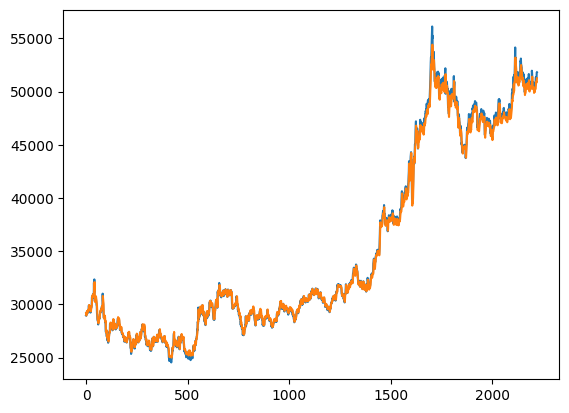

In [16]:
plt.plot(train_predictions['Actuals'])
plt.plot(train_predictions['Train Predictions'])
plt.show()

## Testing

In [23]:
X_train_normalized[1998:1999].shape

(1, 5, 1)

In [17]:
x = X_train_normalized[1998:1999]
x[0][3]

array([0.70115926])

In [18]:
def change_new_value(data, new_value):
    for i in range(4):
        data[0][i] = data[0][i+1]
    
    data[0][4] = new_value
    return data

In [19]:
test_predicted = []
for i in range(222):
    predicted_test_value = model.predict(x, batch_size=1).flatten()
    x = change_new_value(x, predicted_test_value)
    test_predicted.append(predicted_test_value)

test_predicted = denormalize(test_predicted, GLOBAL_MINIMUM, GLOBAL_MAXIMUM)

1/1 [==============================] - 0s 26ms/step


In [20]:
test_predicted

array([[46018.684],
       [45825.03 ],
       [45645.06 ],
       [45491.133],
       [45349.93 ],
       [45216.312],
       [45093.883],
       [44979.918],
       [44873.33 ],
       [44773.36 ],
       [44679.156],
       [44589.953],
       [44505.105],
       [44424.03 ],
       [44346.203],
       [44271.156],
       [44198.473],
       [44127.766],
       [44058.695],
       [43990.93 ],
       [43924.17 ],
       [43858.137],
       [43792.555],
       [43727.164],
       [43661.71 ],
       [43595.93 ],
       [43529.58 ],
       [43462.387],
       [43394.086],
       [43324.402],
       [43253.035],
       [43179.67 ],
       [43103.984],
       [43025.6  ],
       [42944.137],
       [42859.164],
       [42770.223],
       [42676.805],
       [42578.35 ],
       [42474.258],
       [42363.88 ],
       [42246.508],
       [42121.395],
       [41987.766],
       [41844.832],
       [41691.824],
       [41528.05 ],
       [41352.945],
       [41166.156],
       [40967.656],


In [21]:
test_predicted = np.array(test_predicted)
test_predicted = test_predicted.reshape(-1)

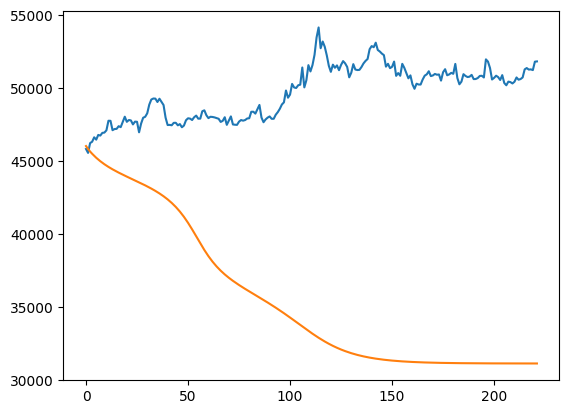

In [22]:
test_predictions = pd.DataFrame(data={'Test Predictions' : test_predicted, 'Actuals' : price_np[2005:]})
plt.plot(test_predictions['Actuals'])
plt.plot(test_predictions['Test Predictions'])
plt.show()